In [1]:
# CM3 eval for historical SST trend

Based on https://github.com/COSIMA/cosima-recipes/blob/8a0205ec0c85d2d08fe94fb3acd901b18f392c37/Cooking-Lessons-101-Tutorials/Apply_function_to_every_gridpoint.ipynb

In [2]:
#parameters

### USER EDIT start
esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-27-07-2026-PD-control/cm3-datastore/cm3-datastore.json'
#'/g/data/ol01/access-om3-output/access-om3-025/MC_25km_jra_ryf-1.0-beta/experiment_datastore.json'
plotfolder='.'
dpi=300
### USER EDIT stop

import matplotlib as mpl
import os
%matplotlib inline
mpl.rcParams['figure.dpi']= dpi

os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-27-07-2026-PD-control/cm3-datastore/cm3-datastore.json
Plot folder path:  .


In [19]:
import numpy as np

from dask.distributed import Client

import xarray as xr
import cf_xarray as cfxr
import cf_xarray.units
import pint_xarray
from pint import application_registry as ureg
import intake

import matplotlib.pyplot as plt
import cmocean as cm
import scipy
import cartopy.crs as ccrs

In [5]:
COLUMNS_WITH_ITERABLES = [
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
]

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=COLUMNS_WITH_ITERABLES
)

In [11]:
sst_cm3 = datastore.search(variable="thetao", frequency="1mon").to_dask(
    xarray_open_kwargs = dict(
        chunks={"z_l": 1, "yh": -1, "xh": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True
    )
).thetao.isel(z_l=0).sel(time=slice('1981','2000')).compute()

Exception ignored in: <function CachingFileManager.__del__ at 0x1471c68c7420>
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [12]:
coords = datastore.search(variable=["geolat", "geolon"]).to_dask(
    xarray_open_kwargs = dict(
        use_cftime=True
    )
).compute()
coords = coords.fillna(0.0)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/source.py:308: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(


In [13]:
sst_cm3 = sst_cm3.assign_coords(coords)

In [15]:
def calc_sst_trend(sst, freq):
    '''
    freq = monthly = 12, daily = 365
    '''

    y = sst.data
    n = y.shape[0]
    x = np.arange(n) / freq
    trend_data = n * (x[:, None, None] * y).sum(axis=0) - x.sum() * y.sum(axis=0)
    trend_data /= n * (x**2).sum() - x.sum()**2

    sst_trend = sst.isel(time=0).copy()
    sst_trend.data[:] = trend_data

    return sst_trend

In [16]:
sst_trend_cm3_monthly = calc_sst_trend(sst_cm3.sel(time=slice('1981','2000')), 12)

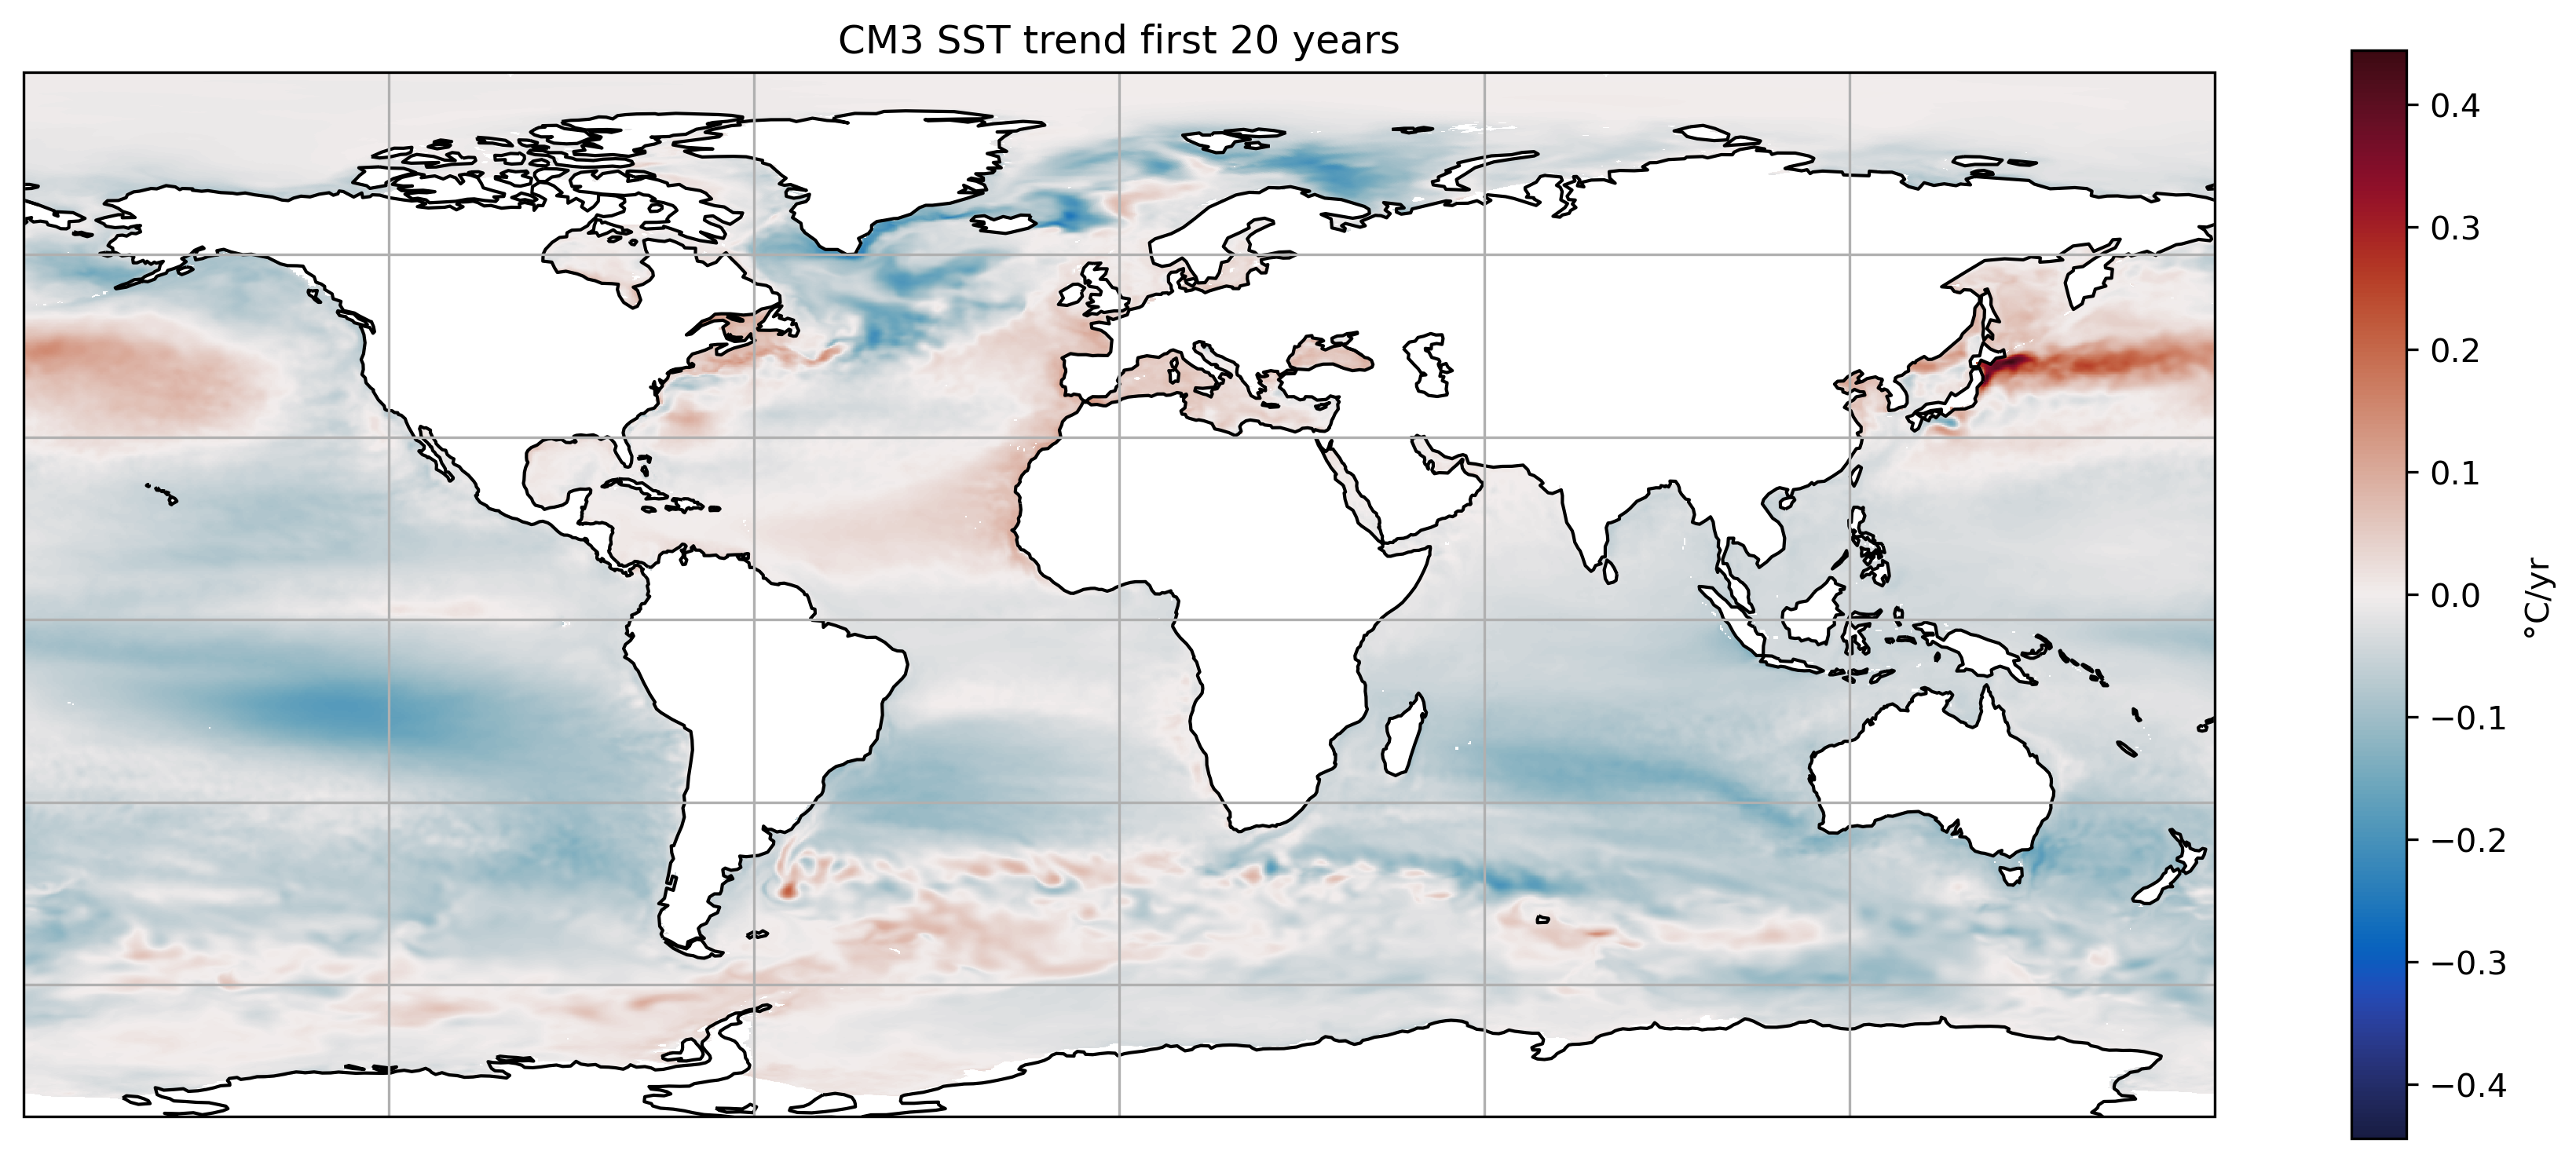

In [35]:
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,6), subplot_kw=dict(projection=proj))

sst_trend_cm3_monthly.plot(ax=ax, x="geolon", y="geolat", cmap=cm.cm.balance, cbar_kwargs={"label": "°C/yr"})
plt.title('CM3 SST trend first 20 years')
ax.coastlines()
_ = ax.gridlines()